<a href="https://colab.research.google.com/github/slr549/ChatBot-LLM/blob/main/assignments/week-5/2411070095_Raki%20Raihan/Ra.Han_05_Advanced_Ensemble_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup & Load Imbalanced Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix
from sklearn.datasets import fetch_openml
from imblearn.over_sampling import SMOTE
import wandb

# Inisialisasi W&B untuk tracking eksperimen
run = wandb.init(project="credit-card-fraud-detection", name="xgboost-smote-real-imbalance")

print("Sedang mengambil dataset asli (imbalanced) dari OpenML...")
# ID 1597 adalah dataset Credit Card Fraud asli yang sangat timpang (284.807 baris)
data = fetch_openml(data_id=1597, as_frame=True, parser='auto')

# Menggabungkan data
df = pd.concat([data.data, data.target], axis=1)
df.columns = [*df.columns[:-1], 'Class']
df['Class'] = df['Class'].astype(int)

# Untuk efisiensi waktu kelas, kita ambil sample 50.000 data namun tetap menjaga ketimpangannya
df = df.sample(n=50000, random_state=42)

print(f"Dataset Berhasil Dimuat! Shape: {df.shape}")
print("\nProporsi Kelas Asli (SANGAT TIMPANG):")
print(df['Class'].value_counts()) # Lihat angka aslinya
print(df['Class'].value_counts(normalize=True)) # Lihat persentasenya

# Log sampel ke W&B
wandb.log({"raw_sample": wandb.Table(dataframe=df.head(100))})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: han-dev321 (han-dev321-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Sedang mengambil dataset asli (imbalanced) dari OpenML...
Dataset Berhasil Dimuat! Shape: (50000, 30)

Proporsi Kelas Asli (SANGAT TIMPANG):
Class
0    49917
1       83
Name: count, dtype: int64
Class
0    0.99834
1    0.00166
Name: proportion, dtype: float64


Visualisasi Masalah Imbalance

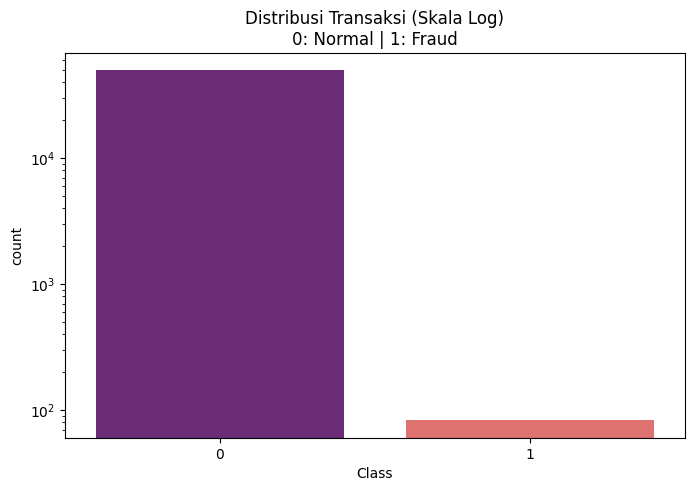

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='magma', hue='Class', legend=False)
plt.title("Distribusi Transaksi (Skala Log)\n0: Normal | 1: Fraud")
plt.yscale('log') # Skala log digunakan agar kelas minoritas (Fraud) terlihat jelas
plt.show()

Handling Imbalance dengan SMOTE

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

# Menggunakan stratify agar proporsi kelas di data latih dan uji tetap sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nMenjalankan SMOTE untuk menyeimbangkan data...")
# SMOTE menciptakan data 'Fraud' sintetis agar AI belajar pola penipuan
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Jumlah data setelah SMOTE: {len(y_train_res)}")
print(f"Proporsi kelas setelah SMOTE (Sudah Seimbang 50:50): \n{pd.Series(y_train_res).value_counts(normalize=True)}")


Menjalankan SMOTE untuk menyeimbangkan data...
Jumlah data setelah SMOTE: 79868
Proporsi kelas setelah SMOTE (Sudah Seimbang 50:50): 
Class
0    0.5
1    0.5
Name: proportion, dtype: float64


Visualisasi Efek SMOTE

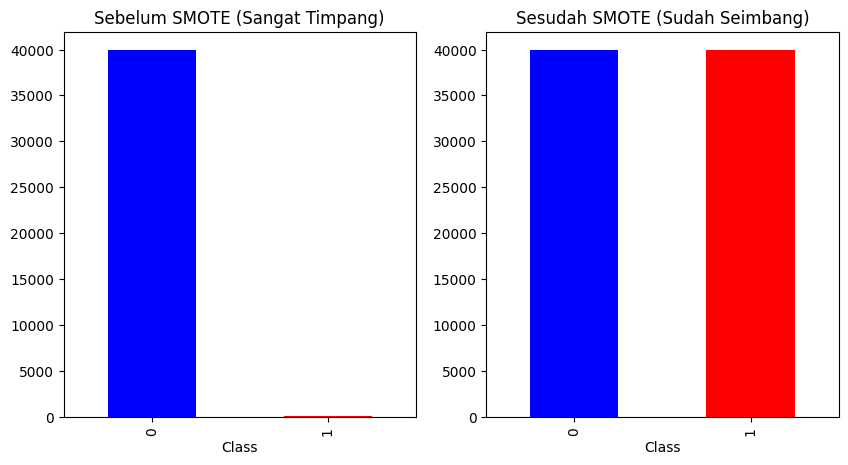

In [4]:
# Bandingkan jumlah data sebelum vs sesudah SMOTE secara visual
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Sebelum SMOTE (Sangat Timpang)")

plt.subplot(1, 2, 2)
pd.Series(y_train_res).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Sesudah SMOTE (Sudah Seimbang)")
plt.show()

Training XGBoost & Evaluasi AUPRC

In [5]:
# XGBoost adalah algoritma 'Boosting' yang memperbaiki kesalahan secara bertahap
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_res, y_train_res)

# Prediksi probabilitas
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# AUPRC adalah metrik wajib untuk data tidak seimbang (fokus pada penemuan Fraud)
auprc = average_precision_score(y_test, y_prob)

wandb.log({
    "AUPRC_Score": auprc,
    "Accuracy_Score": xgb_model.score(X_test, y_test)
})

print(f"\n--- HASIL EVALUASI XGBOOST ---")
print(f"AUPRC Score: {auprc:.4f}")
print("\nClassification Report (Perhatikan Recall pada kelas 1):")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:59:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- HASIL EVALUASI XGBOOST ---
AUPRC Score: 0.6843

Classification Report (Perhatikan Recall pada kelas 1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.65      0.76      0.70        17

    accuracy                           1.00     10000
   macro avg       0.82      0.88      0.85     10000
weighted avg       1.00      1.00      1.00     10000



Visualisasi Confusion Matrix

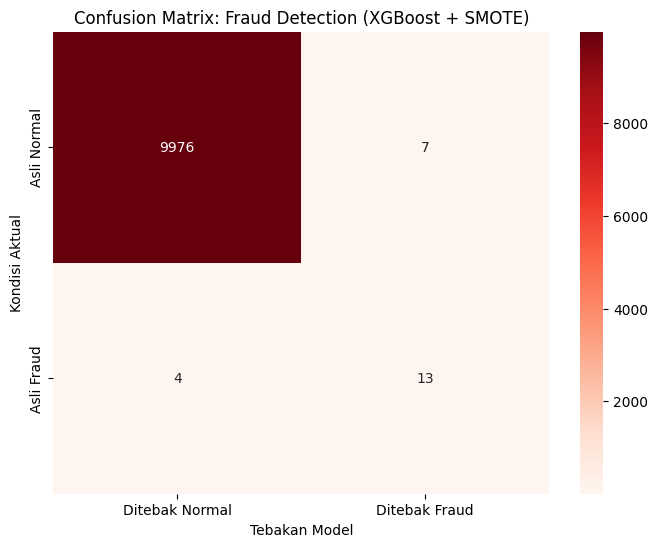

AUPRC_Score,▁
Accuracy_Score,▁
AUPRC_Score,0.68431
Accuracy_Score,0.9989


In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ditebak Normal', 'Ditebak Fraud'],
            yticklabels=['Asli Normal', 'Asli Fraud'])
plt.title("Confusion Matrix: Fraud Detection (XGBoost + SMOTE)")
plt.ylabel("Kondisi Aktual")
plt.xlabel("Tebakan Model")
plt.show()

wandb.finish()